In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from meta import *

df = pd.read_csv(datapath + r"/student_eda.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6378 non-null   int64
 1   Attendance                  6378 non-null   int64
 2   Parental_Involvement        6378 non-null   int64
 3   Access_to_Resources         6378 non-null   int64
 4   Extracurricular_Activities  6378 non-null   int64
 5   Sleep_Hours                 6378 non-null   int64
 6   Previous_Scores             6378 non-null   int64
 7   Motivation_Level            6378 non-null   int64
 8   Internet_Access             6378 non-null   int64
 9   Tutoring_Sessions           6378 non-null   int64
 10  Family_Income               6378 non-null   int64
 11  Teacher_Quality             6378 non-null   int64
 12  School_Type                 6378 non-null   int64
 13  Peer_Influence              6378 non-null   int64
 14  Physical

# Unsupervised Clustering and Dimensionality Reduction

Aşağıdaki algoritmalar kullanılarak veri kümesinde kümeleme ve görselleştirme yapılmaktadır:

1. K-Means Clustering
2. Hierarchical Clustering (Agglomerative)
3. DBSCAN (Density-Based Spatial Clustering)
4. Gaussian Mixture Models (GMM)
5. Principal Component Analysis (PCA)
6. t-SNE (t-Distributed Stochastic Neighbor Embedding)

Cluster distributions:
KMeans: {np.int32(0): np.int64(2045), np.int32(1): np.int64(2060), np.int32(2): np.int64(485), np.int32(3): np.int64(1788)}
Agglomerative: {np.int64(0): np.int64(3610), np.int64(1): np.int64(1664), np.int64(2): np.int64(619), np.int64(3): np.int64(485)}
DBSCAN: {np.int64(-1): np.int64(6378)}
GMM: {np.int64(0): np.int64(2045), np.int64(1): np.int64(2060), np.int64(2): np.int64(485), np.int64(3): np.int64(1788)}

PCA explained variance ratios: [0.05726057 0.0568953 ]


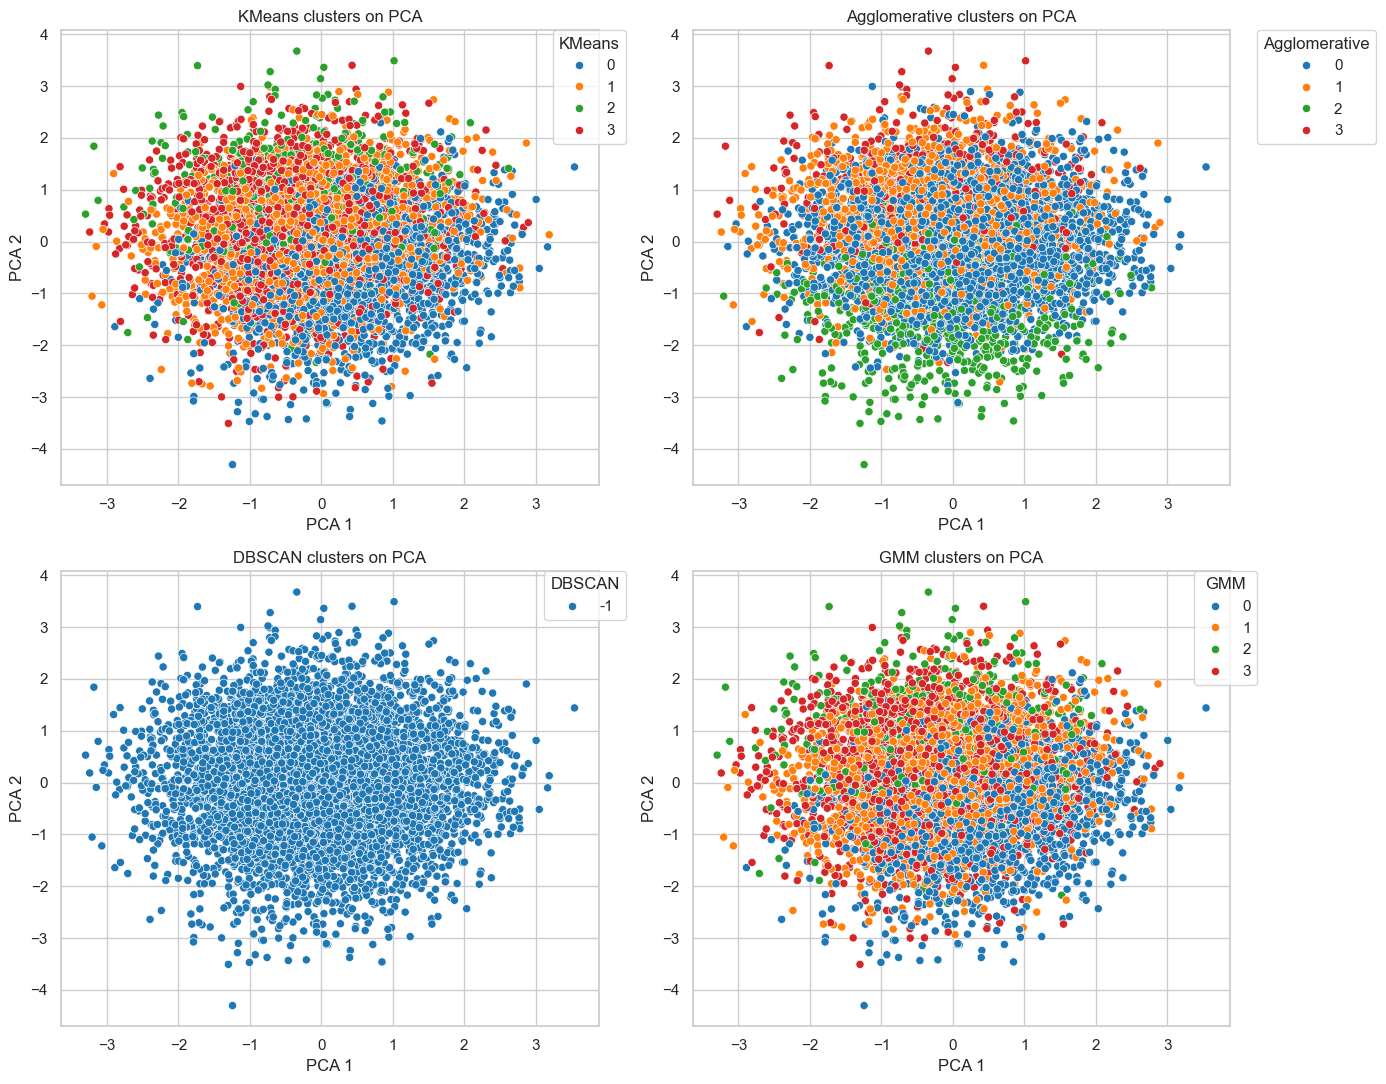

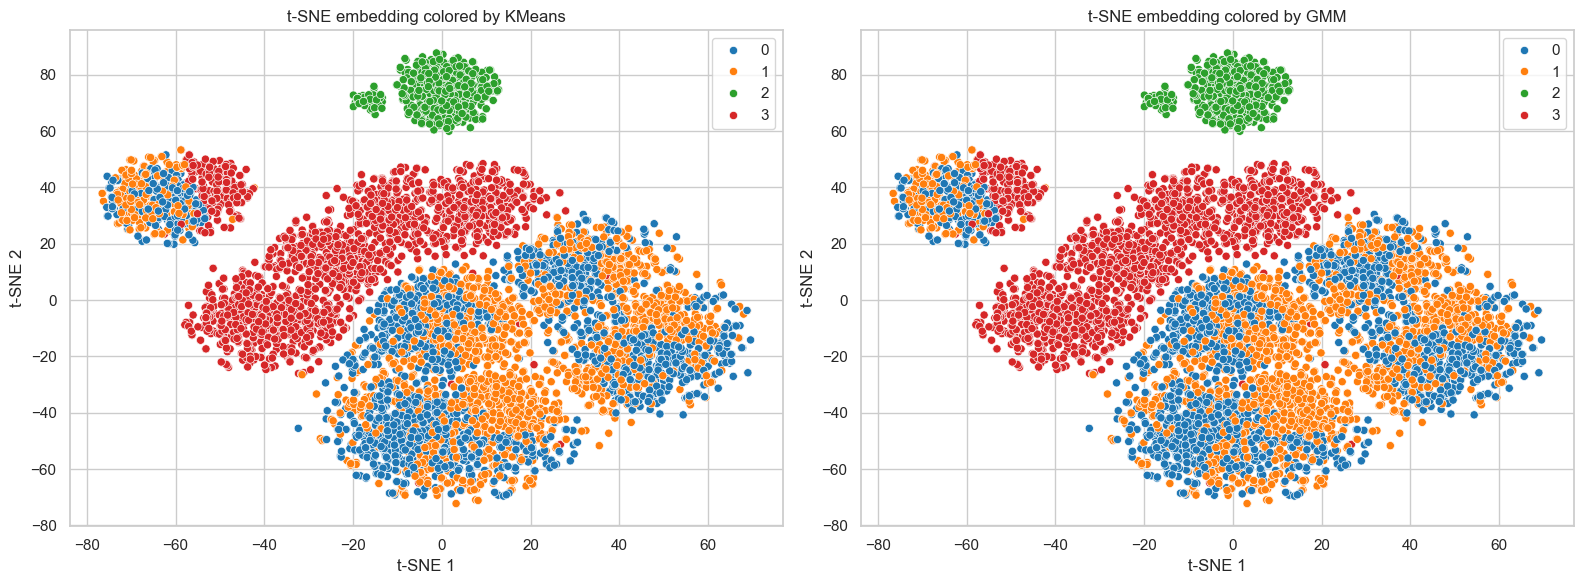

In [5]:
# Select features for clustering
feature_columns = [col for col in df.columns if col != "Exam_Score"]
X = df[feature_columns]

# Scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Agglomerative hierarchical clustering
agglo = AgglomerativeClustering(n_clusters=4)
labels_agglo = agglo.fit_predict(X_scaled)

# DBSCAN density-based clustering
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

# PCA for visualization and dimensionality reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE for 2D embedding visualization
tsne = TSNE(n_components=2, learning_rate=200, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Add cluster labels and reduced dimensions to dataframe
cluster_df = df.copy()
cluster_df["KMeans"] = labels_kmeans
cluster_df["Agglomerative"] = labels_agglo
cluster_df["DBSCAN"] = labels_dbscan
cluster_df["GMM"] = labels_gmm
cluster_df["PCA1"] = X_pca[:, 0]
cluster_df["PCA2"] = X_pca[:, 1]
cluster_df["TSNE1"] = X_tsne[:, 0]
cluster_df["TSNE2"] = X_tsne[:, 1]

# Show cluster sizes and PCA explained variance
print("Cluster distributions:")
for name, labels in [
    ("KMeans", labels_kmeans),
    ("Agglomerative", labels_agglo),
    ("DBSCAN", labels_dbscan),
    ("GMM", labels_gmm),
]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{name}: {dict(zip(unique, counts))}")

print("\nPCA explained variance ratios:", pca.explained_variance_ratio_)

# Plot clusters on PCA components
sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(14, 11))
cluster_methods = [
    ("KMeans", labels_kmeans),
    ("Agglomerative", labels_agglo),
    ("DBSCAN", labels_dbscan),
    ("GMM", labels_gmm),
]
for ax, (name, labels) in zip(axs.flatten(), cluster_methods):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="tab10", legend="full", ax=ax, s=35)
    ax.set_title(f"{name} clusters on PCA")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend(title=name, loc="best", bbox_to_anchor=(1.05, 1), borderaxespad=0.0)

plt.tight_layout()
plt.show()

# Plot t-SNE embeddings for KMeans and GMM
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_kmeans, palette="tab10", legend="full", ax=axs[0], s=35)
axs[0].set_title("t-SNE embedding colored by KMeans")
axs[0].set_xlabel("t-SNE 1")
axs[0].set_ylabel("t-SNE 2")

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_gmm, palette="tab10", legend="full", ax=axs[1], s=35)
axs[1].set_title("t-SNE embedding colored by GMM")
axs[1].set_xlabel("t-SNE 1")
axs[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()